In [1]:
suppressPackageStartupMessages({
  library(data.table)
  library(dplyr)
  library(purrr)
  library(ggplot2)
  library(ggpubr)
  library(rstatix)
  library(forcats)
  library(tidyr)
  library(ggrepel)
  library(rlang)
})

options(warn = -1)

In [2]:
vrd_timepoints <- c(
    'PreTx',
    'PI2C',
    'EI',
    'ASCT60d',
    'ASCT1y',
    'ASCT2y',
    'Healthy'
)

dvrd_timepoints <- c(
    'PreTx',
    'PI2C',
    'EI',
    'Healthy'
)

timepoints_cmap <- c(
    'PreTx' = '#8B0000',
    'PI2C' = '#C20272',
    'EI' = '#7502C2',
    'ASCT60d' = '#0021B0',
    'ASCT90d' = '#2346DE',
    'ASCT1y' = '#038AFF',
    'ASCT2y' = '#008080',
    'Healthy' = '#00470D'
)

vrd_subject_cmap <- c(
    "FH1001" = "#1f77b4", "FH1002" = "#ff7f0e", "FH1003" = "#279e68",
    "FH1004" = "#d62728", "FH1005" = "#aa40fc", "FH1006" = "#8c564b",
    "FH1007" = "#e377c2", "FH1008" = "#b5bd61", "FH1009" = "#17becf",
    "FH1010" = "#aec7e8", "FH1011" = "#ffbb78", "FH1012" = "#98df8a",
    "FH1014" = "#ff9896", "FH1016" = "#c5b0d5", "FH1017" = "#c49c94",
    "FH1018" = "#f7b6d2", "FH1021" = "#dbdb8d"
)

dvrd_subject_cmap <- c(
    "FH1019" = "#32CD32",
    "FH1020" = "#FF1493",
    "FH1022" = "#FFD700",
    "FH1023" = "#8B008B",
    "FH1024" = "#20B2AA",
    "FH1026" = "#FF6347",
    "FH1027" = "#48D1CC",
    "FH1028" = "#BA55D3"
)

In [3]:
# Function to create longitudinal boxplots for flow cytometry data
plot_longitudinal_boxplots <- function(dt, pvals,
                                       data_col = "percent",
                                       pbmc_timepoints = pbmc_tx_tp,
                                       timepoint_colors = timepoints_cmap,
                                       subject_colors,
                                       visit_col = "label.visitDetails",
                                       celltype_col = "aifi_label_l2",
                                       ncol = 6,
                                       point_size = 4,
                                       subtitle,
                                       ytitle) {
  celltype <- unique(dt$Panel)

  # Create visit order using the specified column
  dt[[visit_col]] <- factor(dt[[visit_col]], levels = pbmc_timepoints)
  dt <- dt %>%
    mutate(!!visit_col := factor(.data[[visit_col]]),
      celltype_label = factor(.data[[celltype_col]], levels = levels(factor(.data[[celltype_col]])))
    )

  # Calculate median values for each cell type and timepoint
  # Exclude "Healthy" from median calculations for trend lines
  median_data <- dt %>%
    filter(.data[[visit_col]] != "Healthy") %>%
    group_by(celltype_label, .data[[visit_col]]) %>%
    summarise(
      median_value = median(.data[[data_col]], na.rm = TRUE),
      .groups = "drop"
    ) %>%
    # Convert visit details to numeric for line plotting
    mutate(
      x_position = as.numeric(.data[[visit_col]])
    )

  # Check if significance testing is enabled
  pvals <- pvals %>%
    mutate(
      group1 = factor(group1, levels = pbmc_timepoints),
      group2 = factor(group2, levels = pbmc_timepoints),
      celltype_label = factor(.data[[celltype_col]], levels = levels(dt$celltype_label)),
      p.adj.signif = case_when(
        p.adj < 0.001 ~ "***",
        p.adj < 0.01 ~ "**",
        p.adj < 0.05 ~ "*",
        TRUE ~ "ns"
      )
    ) %>%
    filter(p.adj.signif != "ns")

  # Define comparison order
  comparison_order <- c(
    "PreTx-PI2C", "PreTx-EI", "PI2C-EI", "EI-ASCT60d", "EI-ASCT1y", "EI-ASCT2y",
    "ASCT60d-ASCT1y", "ASCT1y-ASCT2y",
    "PreTx-Healthy", "PI2C-Healthy", "EI-Healthy", "ASCT60d-Healthy", "ASCT1y-Healthy", "ASCT2y-Healthy"
  )

  # Only proceed with positioning if we have p-values
  if (nrow(pvals) > 0) {
    # Calculate y-positions for each cell type separately using dynamic positioning
    pvals_positioned <- pvals %>%
      mutate(
        comparison_id = paste(group1, group2, sep = "-")
      ) %>%
      group_by(celltype_label) %>%
      mutate(
        max_y = max(dt[[data_col]][dt$celltype_label == first(celltype_label)], na.rm = TRUE),
        comparison_rank = match(comparison_id, comparison_order),
        # Calculate dynamic positioning based on the data range
        data_range = max(dt[[data_col]][dt$celltype_label == first(celltype_label)], na.rm = TRUE) -
          min(dt[[data_col]][dt$celltype_label == first(celltype_label)], na.rm = TRUE)
      ) %>%
      arrange(celltype_label, comparison_rank) %>%
      group_by(celltype_label) %>%
      mutate(
        y.position = max_y + (data_range * 0.15) + (row_number() - 1) * (data_range * 0.18)
      ) %>%
      ungroup()

    # Split data by comparison type
    healthy_comparisons <- pvals_positioned %>% filter(group2 == "Healthy")
    other_comparisons <- pvals_positioned %>% filter(group2 != "Healthy")
  } else {
    # Create empty data frames if no p-values
    healthy_comparisons <- data.frame()
    other_comparisons <- data.frame()
  }

  # Calculate jittered positions for alignment
  set.seed(42) # For reproducible jitter positions
  dt <- dt %>%
    group_by(subject.subjectGuid, .data[[visit_col]]) %>%
    mutate(
      x_numeric = as.numeric(.data[[visit_col]]),
      x_jittered = x_numeric + runif(n(), -0.2, 0.2)
    ) %>%
    ungroup()

  # Create the plot
  p <- ggplot(dt, aes_string(x = visit_col, y = data_col)) +
    geom_boxplot(
      aes_string(fill = visit_col),
      alpha = 0.85,
      outlier.shape = NA,
      color = "black"
    ) +
    geom_line(
      aes(x = x_jittered, group = subject.subjectGuid, color = subject.subjectGuid),
      alpha = 0.5,
      linewidth = 0.5
    ) +
    geom_point(
      aes(x = x_jittered, color = subject.subjectGuid),
      size = point_size,
      stroke = 0.4,
      alpha = 0.9
    ) +
    scale_y_continuous(expand = expansion(mult = c(0.05, 0.1))) +
    facet_wrap(~celltype_label, scales = "free_y", ncol = ncol) +
    labs(
      # title = paste("PBMC", celltype, "- frequency analysis over treatment time points"),
      # subtitle = subtitle,
      title = subtitle,
      x = "Visit Timepoints",
      y = ytitle
    ) +
    theme_bw(base_size = 14) +
    theme(
      plot.title = element_text(hjust = 0.5, face = "bold", size = 24, margin = margin(b = 10)),
      plot.subtitle = element_text(size = 20),
      axis.title = element_text(size = 26, face = "bold"),
      axis.text = element_text(size = 22),
      axis.text.x = element_text(angle = 45, hjust = 1),
      legend.position = "right",
      legend.title = element_blank(),
      legend.text = element_text(size = 15, face = "bold"),
      strip.text = element_text(size = 24, face = "bold"),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(), 
      panel.border = element_rect(colour = "black", linewidth = 1)
    ) +
    scale_fill_manual(values = timepoint_colors) +
    scale_color_manual(values = subject_colors)

  # Add colored brackets for healthy comparisons
  if (nrow(healthy_comparisons) > 0) {
    p <- p + stat_pvalue_manual(
      healthy_comparisons,
      label = "p.adj.signif",
      tip.length = 0.01,
      size = 10,
      bracket.size = 1,
      step.increase = 0,
      color = "#00470D",
      inherit.aes = FALSE
    )
  }

  return(p)
}

In [4]:
### Load Metadata
meta <- readxl::read_xlsx("../../data/figure-inputs/metadata/ndmm-rrmm-metadata-2025.xlsx", sheet = 1)
meta$subject.subjectGuid <- meta$Subject
meta <- meta[-c(1:3), ]

### Refactor all 'BRI' subjects as healthy
meta[meta$Cohort %in% c("BR1", "BR2"), ]$Cohort <- "Healthy"

### Load combined files
mmFiles <- fread("../../data/figure-inputs/flow/aggregated_flowdata.csv")

### Join metadata with data files
mmFiles <- dplyr::left_join(mmFiles, distinct(meta[, c("subject.subjectGuid", "Sub_Cohort")]),
  by = "subject.subjectGuid"
)
mmFiles$uniquePopulationName <- mmFiles$aifi_label_l2

mmFiles$label.visitDetails <- factor(mmFiles$label.visitDetails,
  levels = c("PreTx", "PI2C", "EI", "Healthy")
)

In [5]:
healthy_comparisons <- fread("../../data/figure-inputs/flow/dvrd_healthy.csv")
healthy_comparisons %>% head(2)
# pairedComparisons %>% head(2)

healthy_df <- healthy_comparisons
healthy_df$signif_label <- case_when(
  healthy_df$FDR <= 0.001 ~ "***",
  healthy_df$FDR <= 0.01 ~ "**",
  healthy_df$FDR <= 0.05 ~ "*",
  TRUE ~ "ns"
)
healthy_df$label.visitDetails <- healthy_df$Time
healthy_df$group1 <- "VRd"
healthy_df$group2 <- "Healthy"
healthy_df$uniquePopulationName <- healthy_df$Cell

# Assume flow_comparisons is a data.table
healthy_df <- healthy_df[
  , .(
    group1 = Time,
    group2 = "Healthy", # compare each Time vs Healthy
    Log2FC = Log2FC,
    p.adj = FDR, # optional, if present
    p.adj.signif = signif_label, # e.g. "*", "**", "ns"
    y.position = NA_real_, # will compute next
    uniquePopulationName = uniquePopulationName
  )
]

# compute an appropriate y-position automatically per cell
healthy_df[, y.position :=
  sapply(uniquePopulationName, function(c) {
    log10(max(mmFiles[uniquePopulationName == c]$pseudo_alc, na.rm = TRUE) + 1)
  }) * 1.2, by = .(uniquePopulationName, group1)]

V1,VRD,Healthy,panel,Time,Cell,Pval,FDR,Log2FC
<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,4.882111,3.571510,PB1,PreTx,DN B cells,0.0824389,0.2679264,0.4509711
2,6.399840,5.034079,PB1,PreTx,Effector B cells,0.6605449,0.8050391,0.3463080


In [6]:
cells <- c(
  "Plasma cells", "CD16 Monocytes", "CD16+ CD56 dim NK cell",
  "CD56bright NK cell", "CD56 dim NK cell", "Plasmacytoid DC"
)

# Filter data for DVRd cohort, excluding VRd
dvrd_dt <- mmFiles[Sub_Cohort != "DVRd" & !is.na(pseudo_alc)]
dvrd_dt <- dvrd_dt[dvrd_dt$label.visitDetails %in% dvrd_timepoints]
dvrd_dt <- dvrd_dt[dvrd_dt$uniquePopulationName %in% cells]
dvrd_dt <- dvrd_dt[
  dvrd_dt$Cohort == "Healthy" | dvrd_dt$subject.subjectGuid %in% names(dvrd_subject_cmap)
]

# Process healthy comparisons (timepoint vs healthy)
healthy_df <- healthy_comparisons
healthy_df$group1 <- healthy_df$Time
healthy_df$group2 <- "Healthy"
healthy_df$uniquePopulationName <- healthy_df$Cell
healthy_df$p.adj <- healthy_df$FDR

all_comparisons <- healthy_df[, c("group1", "group2", "uniquePopulationName", "p.adj")]
all_comparisons <- all_comparisons[all_comparisons$uniquePopulationName %in% cells]

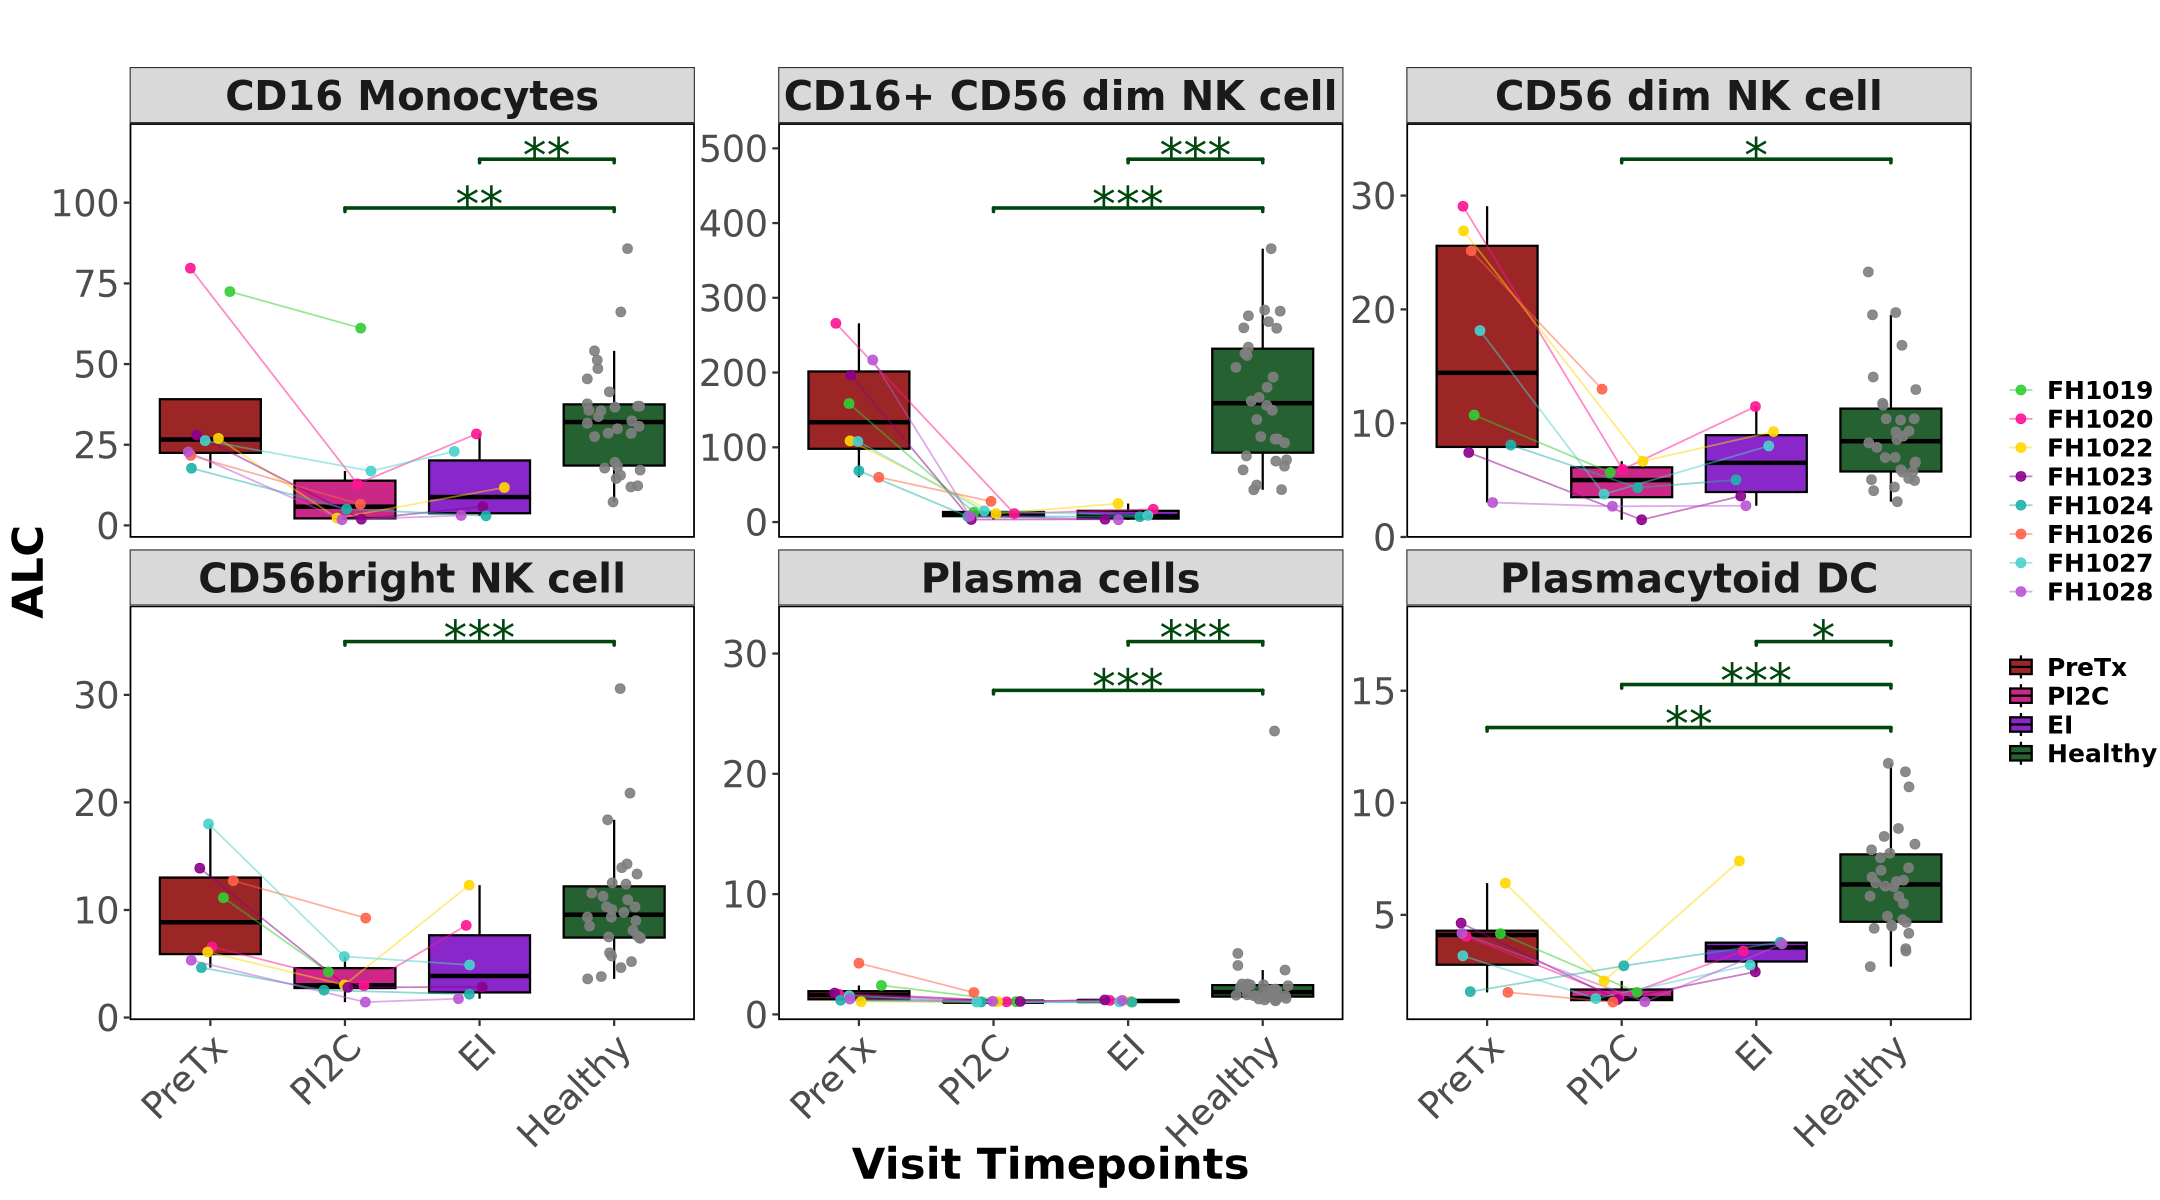

In [7]:
height <- 10
width <- 18

options(repr.plot.width = width, repr.plot.height = height)

p <- plot_longitudinal_boxplots(
  dvrd_dt, all_comparisons,
  data_col = "pseudo_alc",
  celltype_col = "uniquePopulationName",
  subject_colors = dvrd_subject_cmap,
  pbmc_timepoints = dvrd_timepoints,
  point_size = 2.5,
  subtitle = "",
  ncol = 3,
  ytitle = "ALC"
)
p

ggsave("../../data/figure-outputs/supplementary-3/sup_3c.pdf", p, width = width, height = height, dpi = 200, device = cairo_pdf)